# Short-Video Addiction Analysis Using Large-Scale Behavioral Data

Short-video platforms have transformed digital media consumption by promoting rapid, continuous engagement through personalized content feeds. While most users engage at moderate levels, a subset develops persistent, high-intensity usage patterns that resemble behavioral addiction.

Detecting these patterns is challenging because they emerge gradually through everyday interactions. This study investigates how behavioral and temporal usage data can be used to understand and predict short-video addiction.



## Motivation

The motivation for this study comes from both the widespread use of short-video platforms and personal observation of how easily engagement can become excessive. Even short viewing sessions can quickly extend into prolonged periods of continuous scrolling, making it difficult to maintain awareness of time spent.

This reflects a broader issue faced by many users, where seemingly harmless interactions accumulate into habitual overuse. Understanding these patterns is important for identifying early warning signs and encouraging more mindful consumption.

## Research Questions

- RQ1: What behavioral features commonly co-occur among addicted users?
- RQ2: How well can addiction levels be predicted from user behavior?
- RQ3: How do temporal usage patterns differ across users?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

## Dataset Overview

- User-level behavioral data
- Hourly watch time across 24 hours
- Session activity and content diversity
- Addiction labels (non, mild, severe)

In [ ]:
df = pd.read_csv("dataset.csv")
df.head()

,user_id,hour_0_wt,hour_1_wt,hour_2_wt,hour_3_wt,hour_4_wt,hour_5_wt,hour_6_wt,hour_7_wt,hour_8_wt,...,gender,month_chronological_order,preds_3_label_criteria_label,preds_soft_label,watch_all_per_day_min,midnight_wt_min,morning_wt_min,noon_wt_min,afternoon_wt_min,evening_wt_min
0,31,38.500000,794.333333,90.666667,0.0,0.0,0.0,0.0,0.0,197.0,...,F,1,Severely Addicted,Addicted,27,15,5,0,43,96
1,31,748.142857,521.166667,169.500000,0.0,0.0,0.0,0.0,0.0,200.5,...,F,2,Severely Addicted,Addicted,83,23,50,23,48,68
2,31,491.307692,897.200000,901.333333,0.0,0.0,0.0,0.0,67.0,0.0,...,F,3,Severely Addicted,Addicted,82,38,38,15,39,76
3,31,0.000000,0.000000,308.000000,0.0,378.0,678.0,0.0,317.4,1174.0,...,F,4,Severely Addicted,Addicted,55,22,53,18,35,41
4,31,261.000000,490.500000,82.250000,0.0,0.0,0.0,0.0,1279.0,0.0,...,F,5,Mildly Addicted,Addicted,33,13,37,1,24,58


In [ ]:
df['gender'] = LabelEncoder().fit_transform(df['gender'])
df['label'] = LabelEncoder().fit_transform(df['preds_3_label_criteria_label'])

df = df.drop(columns=['preds_soft_label', 'preds_3_label_criteria_label'])

/tmp/ipykernel_27266/1125740533.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


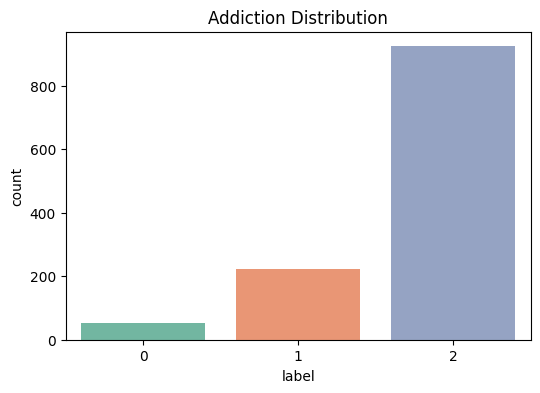

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title("Addiction Distribution")
plt.show()

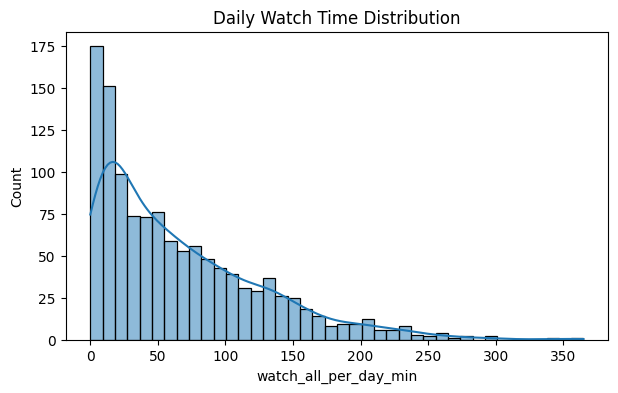

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df['watch_all_per_day_min'], bins=40, kde=True)
plt.title("Daily Watch Time Distribution")
plt.show()

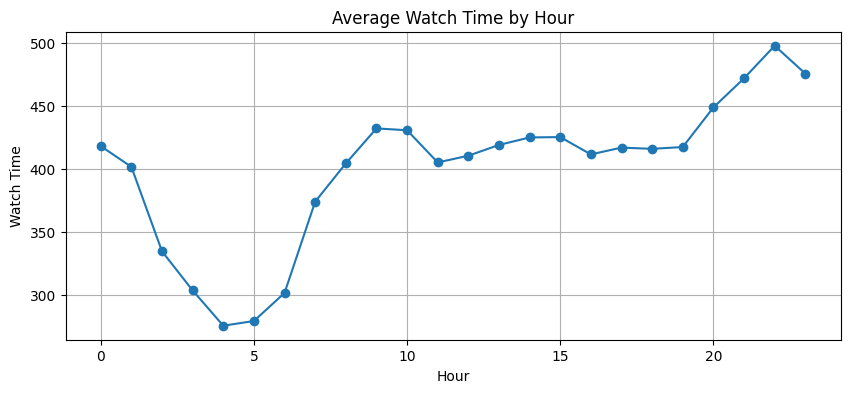

In [ ]:
hour_cols = [f'hour_{i}_wt' for i in range(24)]
hour_avg = df[hour_cols].mean()

plt.figure(figsize=(10,4))
plt.plot(range(24), hour_avg.values, marker='o')
plt.title("Average Watch Time by Hour")
plt.xlabel("Hour")
plt.ylabel("Watch Time")
plt.grid()
plt.show()

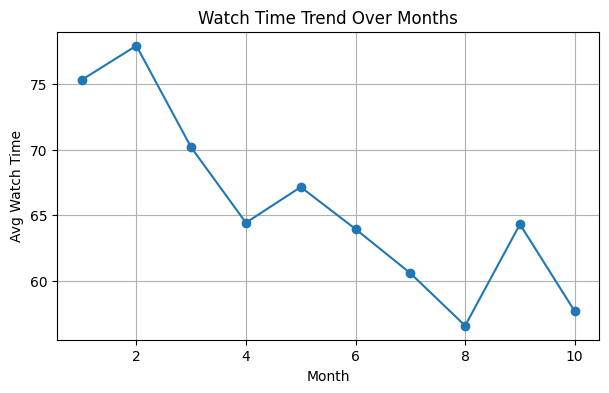

In [ ]:
monthly = df.groupby('month_chronological_order')['watch_all_per_day_min'].mean()

plt.figure(figsize=(7,4))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title("Watch Time Trend Over Months")
plt.xlabel("Month")
plt.ylabel("Avg Watch Time")
plt.grid()
plt.show()

In [ ]:
df['late_night'] = df['midnight_wt_min']
df['high_watch'] = (df['watch_all_per_day_min'] > df['watch_all_per_day_min'].quantile(0.75)).astype(int)
df['low_diversity'] = (df['category_count_unique'] < df['category_count_unique'].quantile(0.25)).astype(int)

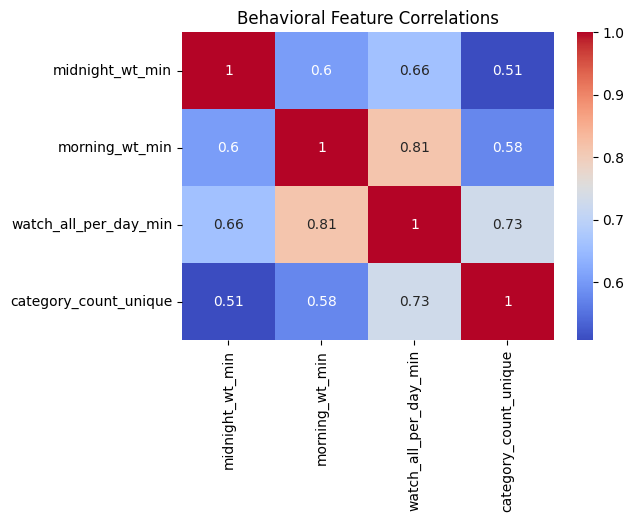

In [ ]:
features = ['midnight_wt_min', 'morning_wt_min',
             'watch_all_per_day_min', 'category_count_unique']

plt.figure(figsize=(6,4))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title("Behavioral Feature Correlations")
plt.show()

In [ ]:
X = df[['watch_all_per_day_min',
        'session_all_per_day',
        'category_count_unique',
        'midnight_wt_min',
        'age']]

y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.30      0.40        10
           1       0.66      0.60      0.63        45
           2       0.87      0.91      0.89       185

    accuracy                           0.83       240
   macro avg       0.71      0.60      0.64       240
weighted avg       0.82      0.83      0.82       240



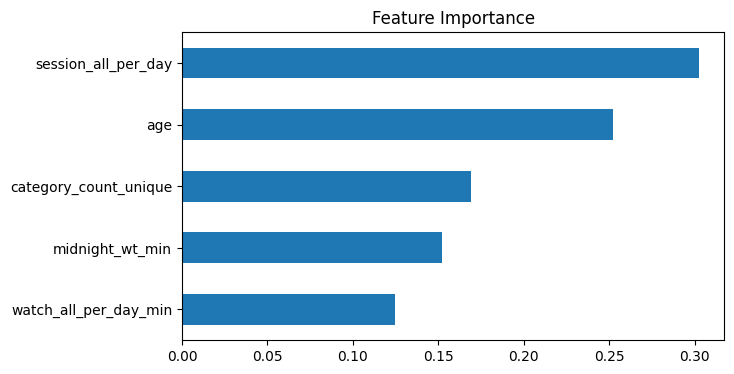

In [ ]:
imp = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(7,4))
imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

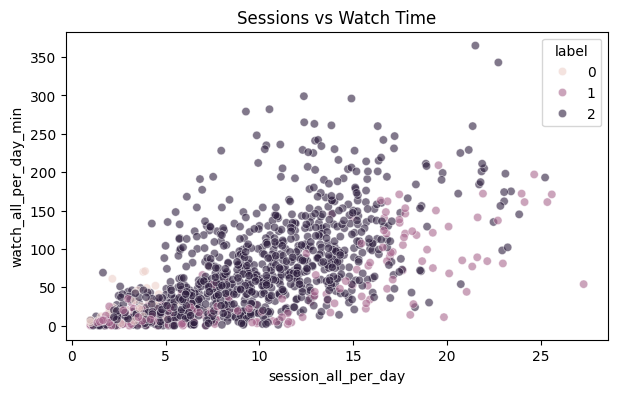

In [ ]:
plt.figure(figsize=(7,4))

sns.scatterplot(
    x='session_all_per_day',
    y='watch_all_per_day_min',
    hue='label',
    data=df,
    alpha=0.6
)

plt.title("Sessions vs Watch Time")
plt.show()

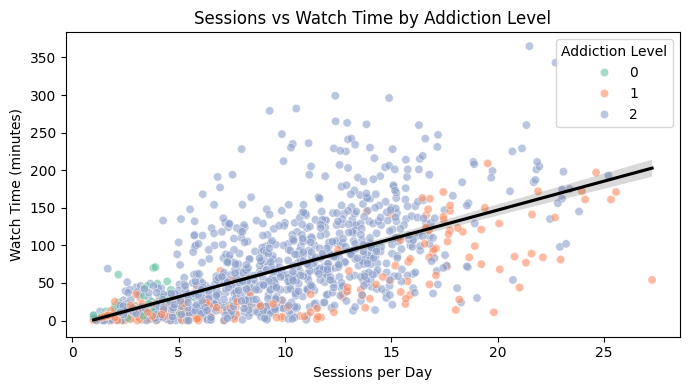

In [ ]:
plt.figure(figsize=(7,4))

sns.scatterplot(
    data=df,
    x='session_all_per_day',
    y='watch_all_per_day_min',
    hue='label',
    alpha=0.6,
    palette='Set2'
)

sns.regplot(
    data=df,
    x='session_all_per_day',
    y='watch_all_per_day_min',
    scatter=False,
    color='black'
)

plt.title("Sessions vs Watch Time by Addiction Level")
plt.xlabel("Sessions per Day")
plt.ylabel("Watch Time (minutes)")
plt.legend(title="Addiction Level")

plt.tight_layout()
plt.show()

# Key Findings
* Watch time increases with session frequency across all users.
The upward trend indicates a strong positive relationship between number of sessions and total watch time, suggesting that frequent engagement is a key driver of overall consumption.
* Highly addicted users cluster at high sessions and high watch time.
Users in the highest addiction category (label 2) are concentrated in the upper-right region of the plot, reflecting both frequent app usage and prolonged viewing durations.
* Moderate users show overlap but lower intensity.
Users with mild addiction (label 1) partially overlap with severe users but generally exhibit lower watch time for similar session counts, indicating less intensive consumption per session.
* Low-addiction users remain in low engagement regions. Non-addicted users (label 0) are primarily located in the lower-left area, characterized by fewer sessions and shorter total watch time.
* Separation emerges at higher activity levels. While user groups overlap at low session counts, distinctions between addiction levels become clearer as session frequency increases, suggesting that high engagement amplifies behavioral differences.

# Conclusion

This study shows that short-video addiction is strongly associated with increasing behavioral intensity, particularly in the form of frequent sessions and prolonged watch time. The analysis reveals a clear positive relationship between session frequency and total consumption, with highly addicted users consistently occupying the highest ranges of both.

While lower-engagement users remain clustered in low-activity regions, differences between addiction levels become more pronounced as usage increases. This suggests that addiction is not simply a matter of participation, but of escalating engagement patterns that combine frequency and duration.

Overall, the findings demonstrate that behavioral signals alone are sufficient to distinguish levels of addiction, and that simple usage metrics, especially session count and watch time, can serve as effective indicators for identifying high-risk users.

These insights highlight the potential for early detection systems that monitor rapid increases in user activity, enabling timely intervention before extreme usage patterns become established.